In [1]:
# =====================================================================
# CELL 1: GAUSSIAN NAIVE BAYES (CONTINUOUS FEATURES)
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


In [2]:

# 1. Load the Data
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target




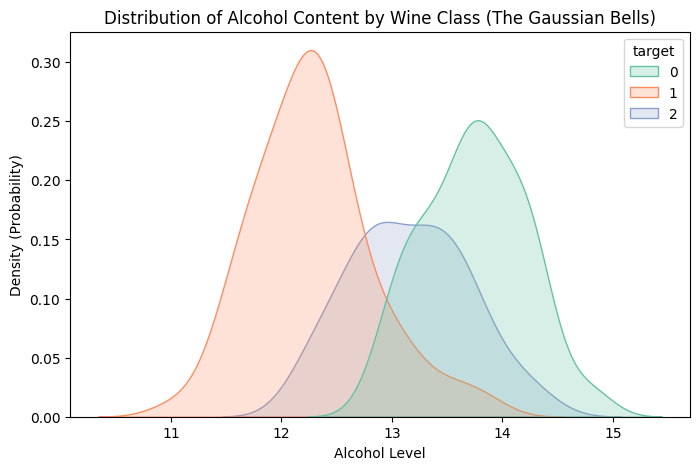

In [3]:

# 2. Exploratory Data Analysis (EDA)
# We plot the distribution of 'alcohol' for each class of wine.
# Notice how each class naturally forms a bell curve! This visual proves 
# exactly WHY we use the Gaussian (Normal) Distribution PDF for this data.
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='alcohol', hue='target', fill=True, palette='Set2')
plt.title("Distribution of Alcohol Content by Wine Class (The Gaussian Bells)")
plt.xlabel("Alcohol Level")
plt.ylabel("Density (Probability)")
plt.show()

In [4]:

# 3. Prepare the Model
# We split the data: 80% for training, 20% for hidden testing
X = df[['alcohol', 'malic_acid', 'ash', 'magnesium']] # Selecting 4 continuous features
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:

# Initialize the model. 
# Remember: var_smoothing=1e-9 is the default, fixing the zero-variance edge case.
gaussian_model = GaussianNB()
gaussian_model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [6]:

# 4. Manual Input and Prediction
# Imagine we just tested a new glass of wine in the lab.
# We input its chemical values in the exact order: [alcohol, malic_acid, ash, magnesium]
manual_wine_test = np.array([[13.5, 2.0, 2.5, 100.0]])

# The model calculates the Gaussian PDF for these values against all 3 classes
prediction = gaussian_model.predict(manual_wine_test)
probabilities = gaussian_model.predict_proba(manual_wine_test)

print("--- GAUSSIAN PREDICTION RESULTS ---")
print(f"Predicted Wine Class: {wine.target_names[prediction[0]]}")
print(f"Probabilities (Class 0, 1, 2): {np.round(probabilities[0], 4)}")

--- GAUSSIAN PREDICTION RESULTS ---
Predicted Wine Class: class_0
Probabilities (Class 0, 1, 2): [0.7489 0.0211 0.2299]


d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
